Eye closed: 0.10, Avg. confidence: 0.93, Avg. diameter: 61.03


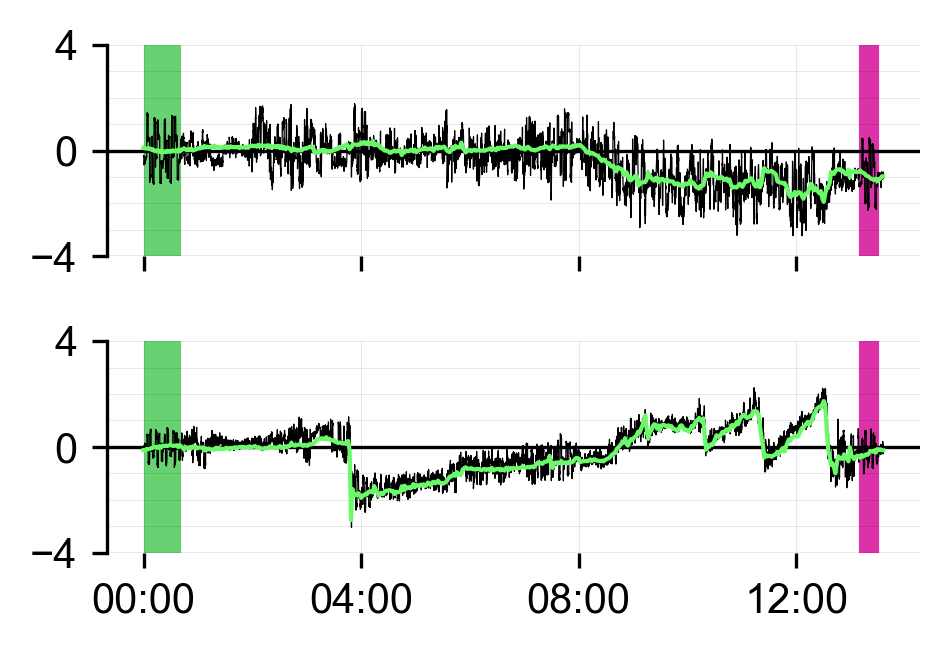

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import mocet
plt.style.use('default')

# 'sub-JJY', 'ses-07', 'task-mcHERDING', 'run-3'
subject = 'sub-JJY'
session = 'ses-07'
task = 'task-mcHERDING'
run = 'run-3'
task_duration = 816
calibration_offset_start = 0.55
calibration_offset_end = -0.55

root = f'../../_DATA/{subject}/{session}'
log_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_log.csv'
data_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_dat.txt' 
confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'
history_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_his.txt'
start, _, _ = mocet.utils.get_avotec_history(history_fname)
            
def get_timeformat(seconds):
    m, s = divmod(seconds, 60)
    string = f'{m:02d}:{s:02d}'
    return string

calibration_onsets = [1, 494]
calibration_points = [24, 12]
interval = 1.6 

pupil_data, pupil_timestamps, pupil_confidence, pupil_diameter = mocet.utils.clean_avotec_data(log_fname,
                                                                         data_fname,
                                                                         start=start,
                                                                         duration=task_duration)

pupil_validity = np.sum(np.isnan(pupil_confidence))/len(pupil_confidence)
mean_pupil_confidence = np.nanmean(pupil_confidence)
mean_pupil_diameter = np.nanmean(pupil_diameter)
print(f"Eye closed: {pupil_validity:2.2f}, Avg. confidence: {mean_pupil_confidence:2.2f}, Avg. diameter: {mean_pupil_diameter:2.2f}")

            
_, coef_, dedrift_regressor = mocet.apply_mocet(pupil_data, confounds_fname, return_weights=True)

avg_pupil_diameter_mm = 5
pupil_diameter_mm_per_px = avg_pupil_diameter_mm / np.nanmean(pupil_diameter)
motion_params = mocet.get_motion_params(confounds_fname, large_motion_params=False)

pupil_data_x = pupil_data[:,0] - np.mean(pupil_data[:int(1.6*25*60),0])
pupil_data_y = pupil_data[:,1] - np.mean(pupil_data[:int(1.6*25*60),1])

dedrift_regressor_x = dedrift_regressor[:,0] - np.mean(dedrift_regressor[:int(1.6*25*60),0])
dedrift_regressor_y = dedrift_regressor[:,1] - np.mean(dedrift_regressor[:int(1.6*25*60),1])


fig, axes = plt.subplots(2,1,figsize=(3.5,2.2), dpi=300, sharex=True)
for ax in axes:
    ax.axhline(y=0, color='k', linestyle='-', alpha=1.0, lw=0.8, zorder=3)
    ax.spines[['right', 'top','bottom']].set_visible(False)
plt.subplots_adjust(hspace=0.4)

axes[0].plot(pupil_timestamps/1600.0, pupil_data_x*pupil_diameter_mm_per_px, lw=0.3, c='k', zorder=100)
axes[1].plot(pupil_timestamps/1600.0, pupil_data_y*pupil_diameter_mm_per_px, lw=0.3, c='k', zorder=100)
axes[0].plot(pupil_timestamps/1600.0, dedrift_regressor_x*pupil_diameter_mm_per_px, lw=1, c='#6afa69', zorder=100)
axes[1].plot(pupil_timestamps/1600.0, dedrift_regressor_y*pupil_diameter_mm_per_px, lw=1, c='#6afa69', zorder=100)


offset = 4
axes[0].set_ylim(-offset, offset)
axes[0].set_yticks([-offset, 0, offset])
axes[1].set_ylim(-offset, offset)
axes[1].set_yticks([-offset, 0, offset])

xticks = [0,240,480,720]
TR = 1.6
axes[1].set_xticks(np.array(xticks)/interval)
axes[1].set_xticklabels([get_timeformat(s) for s in xticks])
color_list = ['#68d171', '#db32a7']
for ax in [axes[0], axes[1]]:
    for i in [-4+0.04, -3, -2, -1, 0, 1, 2, 3, 4]:
        ax.axhline(y=i, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=2)
    for xt in xticks:
        ax.axvline(x=xt/TR, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=2)
    offset_cal = calibration_onsets[0]
    start = (offset_cal) + calibration_offset_start
    end = (offset_cal+calibration_points[0]) + calibration_offset_end
    ax.axvspan(start, end, alpha=1.0, color='#68d171', zorder=0)
    
    offset_val = calibration_onsets[1]
    start = (offset_val) + calibration_offset_start
    end = (offset_val+calibration_points[1]) + calibration_offset_end
    ax.axvspan(start, end, alpha=1.0, color='#db32a7', zorder=0)

for ax in axes.flatten():
    for tick in ax.get_yticklabels():
        tick.set_fontname("Arial")
    for tick in ax.get_xticklabels():
        tick.set_fontname("Arial")

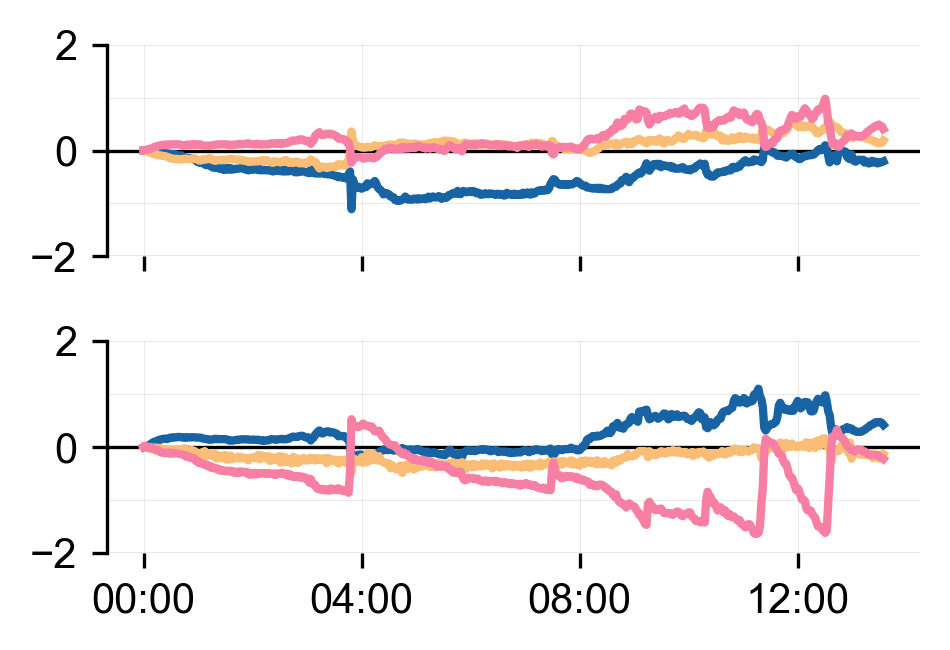

In [5]:
import pandas as pd
motion_param_labels = ['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

root = f'../../_DATA/{subject}/{session}'
confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'
fmriprep_confounds = pd.read_csv(confounds_fname, delimiter='\t')
motion_params = fmriprep_confounds[motion_param_labels].to_numpy()
motion_params = motion_params - motion_params[0,:]
motion_params = -motion_params
#motion_params = mocet.get_motion_params(confounds_fname, large_motion_params=False)

fig, axes = plt.subplots(2,1,figsize=(3.5,2.2), dpi=300, sharex=True)

color_list = ["#1763a3","#f9bd75","#f77fa4","#1763a3","#f9bd75","#f77fa4"]
trans_offset = 2
for i in range(0,3):
    axes[1].plot(motion_params[:,i], lw=2, zorder=100, c=color_list[i])
    axes[1].set_ylim(-trans_offset, trans_offset)
    axes[1].set_yticks([-trans_offset,0,trans_offset])

rot_offset = 2
for i in range(3,6):
    axes[0].plot(np.rad2deg(motion_params[:,i]), lw=2, zorder=100, c=color_list[i])
    axes[0].set_ylim(-rot_offset, rot_offset)
    axes[0].set_yticks([-rot_offset,0,rot_offset])

TR = 1.6
xticks = np.array([0,240,480,720])
axes[1].set_xticks(xticks/TR)
axes[1].set_xticklabels([get_timeformat(s) for s in xticks])

for ax in axes:
    for i in [-2+0.02, -1, 0, 1, 2]:
        ax.axhline(y=i, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=2)
    for xt in xticks:
        ax.axvline(x=xt/TR, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=2)
    ax.axhline(y=0, color='k', linestyle='-', alpha=1.0, lw=0.8, zorder=0)
    ax.spines[['right', 'top','bottom']].set_visible(False)
plt.subplots_adjust(hspace=0.4)

for ax in axes.flatten():
    for tick in ax.get_yticklabels():
        tick.set_fontname("Arial")
    for tick in ax.get_xticklabels():
        tick.set_fontname("Arial")

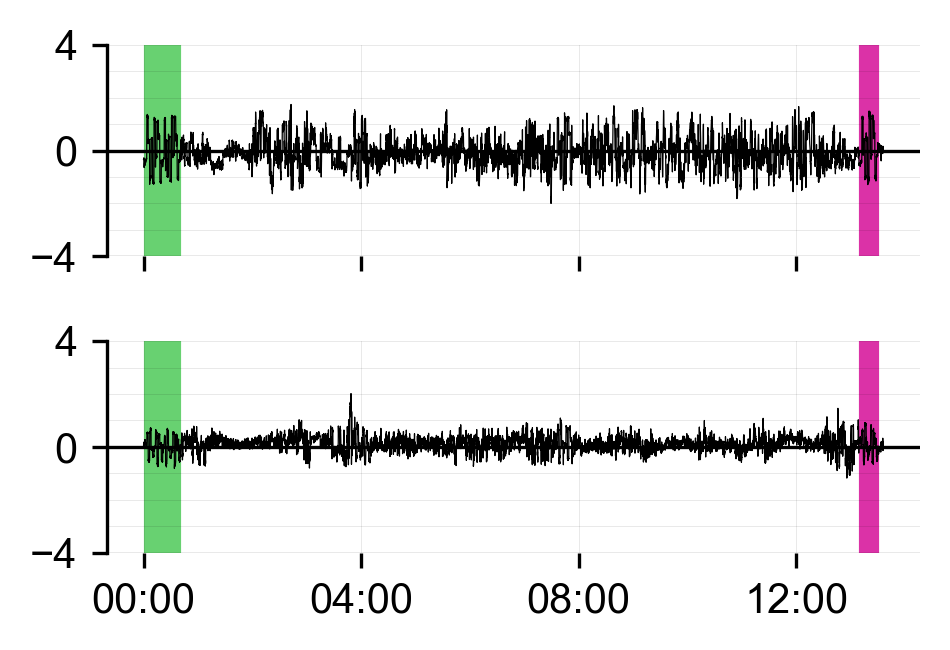

In [6]:

root = f'../../_DATA/{subject}/{session}'
log_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_log.csv'
data_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_dat.txt' 
confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'
history_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_his.txt'
start, _, _ = mocet.utils.get_avotec_history(history_fname)

pupil_data, pupil_timestamps, _, pupil_diameter = mocet.utils.clean_avotec_data(log_fname,
                                                                         data_fname,
                                                                         start=start,
                                                                         duration=task_duration)

pupil_data, coef_, dedrift_regressor = mocet.apply_mocet(pupil_data, confounds_fname, return_weights=True)

avg_pupil_diameter_mm = 5
pupil_diameter_mm_per_px = avg_pupil_diameter_mm / np.nanmean(pupil_diameter)
motion_params = mocet.get_motion_params(confounds_fname, large_motion_params=False)

pupil_data_x = pupil_data[:,0] - np.mean(pupil_data[:int(1.6*25*60),0])
pupil_data_y = pupil_data[:,1] - np.mean(pupil_data[:int(1.6*25*60),1])

dedrift_regressor_x = dedrift_regressor[:,0] - np.mean(dedrift_regressor[:int(1.6*25*60),0])
dedrift_regressor_y = dedrift_regressor[:,1] - np.mean(dedrift_regressor[:int(1.6*25*60),1])

fig, axes = plt.subplots(2,1,figsize=(3.5,2.2), dpi=300, sharex=True)
for ax in axes:
    ax.axhline(y=0, color='k', linestyle='-', alpha=1.0, lw=0.8, zorder=3)
    ax.spines[['right', 'top','bottom']].set_visible(False)
plt.subplots_adjust(hspace=0.4)

axes[0].plot(pupil_timestamps/1600.0, pupil_data_x*pupil_diameter_mm_per_px, lw=0.3, c='k', zorder=100)
axes[1].plot(pupil_timestamps/1600.0, pupil_data_y*pupil_diameter_mm_per_px, lw=0.3, c='k', zorder=100)

offset = 4
axes[0].set_ylim(-offset, offset)
axes[0].set_yticks([-offset, 0, offset])
axes[1].set_ylim(-offset, offset)
axes[1].set_yticks([-offset, 0, offset])

xticks = [0,240,480,720]
TR = 1.6
axes[1].set_xticks(np.array(xticks)/interval)
axes[1].set_xticklabels([get_timeformat(s) for s in xticks])
color_list = ['#68d171', '#db32a7']
for ax in [axes[0], axes[1]]:
    for i in [-4+0.04, -3, -2, -1, 0, 1, 2, 3, 4]:
        ax.axhline(y=i, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=2)
    for xt in xticks:
        ax.axvline(x=xt/TR, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=2)
    offset_cal = calibration_onsets[0]
    start = (offset_cal) + calibration_offset_start
    end = (offset_cal+calibration_points[0]) + calibration_offset_end
    ax.axvspan(start, end, alpha=1.0, color='#68d171', zorder=0)
    
    offset_val = calibration_onsets[1]
    start = (offset_val) + calibration_offset_start
    end = (offset_val+calibration_points[1]) + calibration_offset_end
    ax.axvspan(start, end, alpha=1.0, color='#db32a7', zorder=0)

for ax in axes.flatten():
    for tick in ax.get_yticklabels():
        tick.set_fontname("Arial")
    for tick in ax.get_xticklabels():
        tick.set_fontname("Arial")